# Simulation Data Analysis Tutorial

This notebook demonstrates how to use DeepSpak to process three-modal spatial multi-omics data (RNA + Protein + ATAC).

## 1. Import Libraries and Set Random Seed

In [55]:
# =============================================================================
# Import required libraries
# =============================================================================

import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import torch
import numpy as np
import random
import pandas as pd
import scanpy as sc
import argparse
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

In [56]:
def setup_seed(seed=2020):
    """
    Set random seed to ensure reproducibility.
    
    Args:
        seed: Random seed value (default: 2020)
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    os.environ['PYTHONHASHSEED'] = str(seed)

setup_seed(2020)

## 2. Load Data

In [57]:
# =============================================================================
# Load three-modal spatial multi-omics data
# =============================================================================

# Data directory path - please replace this path with your data download path
file_fold = 'E:/code/mymodel2/data/Simulation/'

# Load RNA data (omics1)
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
print(f"Loaded RNA data: {adata_omics1.shape[0]} cells, {adata_omics1.shape[1]} genes")

# Load Protein data (omics2)
adata_omics2 = sc.read_h5ad(file_fold + 'adata_ADT.h5ad')
print(f"Loaded Protein data: {adata_omics2.shape[0]} cells, {adata_omics2.shape[1]} proteins")

# Load ATAC data (omics3)
adata_omics3 = sc.read_h5ad(file_fold + 'adata_ATAC.h5ad')
print(f"Loaded ATAC data: {adata_omics3.shape[0]} cells, {adata_omics3.shape[1]} peaks")


adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()
adata_omics3.var_names_make_unique()

Loaded RNA data: 1296 cells, 1000 genes
Loaded Protein data: 1296 cells, 100 proteins
Loaded ATAC data: 1296 cells, 1000 peaks


## 3. Data Preprocessing and Feature Extraction

In [58]:
from DeepSpak.preprocess_3M import clr_normalize_each_cell, pca, construct_neighbor_graph, lsi
n_protein = adata_omics2.n_vars
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)

adata_omics1_high = adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=n_protein)
print(f"RNA PCA feature shape: {adata_omics1.obsm['feat'].shape}")

adata_omics2 = clr_normalize_each_cell(adata_omics2)
adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=n_protein)
print(f"Protein PCA feature shape: {adata_omics2.obsm['feat'].shape}")

sc.pp.highly_variable_genes(adata_omics3, flavor="seurat_v3", n_top_genes=3000)
lsi(adata_omics3, use_highly_variable=False, n_components=n_protein + 1)
adata_omics3.obsm['feat'] = adata_omics3.obsm['X_lsi'].copy()
print(f"ATAC LSI feature shape: {adata_omics3.obsm['feat'].shape}")

RNA PCA feature shape: (1296, 100)
Protein PCA feature shape: (1296, 100)
ATAC LSI feature shape: (1296, 100)


## 4. Construct Neighbor Graph

In [59]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, adata_omics3)
print("Neighbor graph constructed successfully")

Neighbor graph constructed successfully


## 5. Configure Model Parameters

In [60]:
# =============================================================================
# Model configuration parameters
# In Jupyter Notebook, use argparse.Namespace instead of parse_args()
# =============================================================================

args = argparse.Namespace(
    # Training parameters
    batch_size=1296,                    # Batch size
    temperature_f=2.7,                  # Temperature parameter for contrastive learning
    learning_rate=0.0001,               # Learning rate
    weight_decay=0.01,                  # Weight decay (regularization)
    rec_epochs=280,                     # Number of reconstruction epochs
    fine_tune_epochs=80,                # Number of fine-tuning epochs
    
    # Model architecture
    low_feature_dim=128,                # Low-level feature dimension
    high_feature_dim=256,               # High-level feature dimension
    alpha=0.8,                          # Alpha parameter for graph fusion
    walk_steps=4,                       # Number of random walk steps
    
    # Clustering settings
    n_clusters=5                        # Number of clusters
)

print("Model configuration:")
print(f"  - Batch size: {args.batch_size}")
print(f"  - Learning rate: {args.learning_rate}")
print(f"  - Reconstruction epochs: {args.rec_epochs}")
print(f"  - Fine-tuning epochs: {args.fine_tune_epochs}")
print(f"  - Number of clusters: {args.n_clusters}")

Model configuration:
  - Batch size: 1296
  - Learning rate: 0.0001
  - Reconstruction epochs: 280
  - Fine-tuning epochs: 80
  - Number of clusters: 5


## 6. Model Training

In [61]:
# Train the DeepSpak model
setup_seed(2020)

# Import three-modal trainer
from DeepSpak.test_train_3M import SpatialOmicsTrainer

# Initialize trainer
trainer = SpatialOmicsTrainer(args, data)
print("Starting training...")
output = trainer.train()
print("Training completed!")

Training mode: Three-modal
Starting training...
Pre-train Epoch 1 Loss:13.716478
Pre-train Epoch 2 Loss:13.696265
Pre-train Epoch 3 Loss:13.676001
Pre-train Epoch 4 Loss:13.654441
Pre-train Epoch 5 Loss:13.632743


d:\anaconda3\envs\sedrenv\Lib\site-packages\torch\_compile.py:24: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return torch._dynamo.disable(fn, recursive)(*args, **kwargs)


Pre-train Epoch 6 Loss:13.611157
Pre-train Epoch 7 Loss:13.588241
Pre-train Epoch 8 Loss:13.564614
Pre-train Epoch 9 Loss:13.540131
Pre-train Epoch 10 Loss:13.515328
Pre-train Epoch 11 Loss:13.490114
Pre-train Epoch 12 Loss:13.465021
Pre-train Epoch 13 Loss:13.439215
Pre-train Epoch 14 Loss:13.413048
Pre-train Epoch 15 Loss:13.386912
Pre-train Epoch 16 Loss:13.361522
Pre-train Epoch 17 Loss:13.335764
Pre-train Epoch 18 Loss:13.309358
Pre-train Epoch 19 Loss:13.281692
Pre-train Epoch 20 Loss:13.255330
Pre-train Epoch 21 Loss:13.227392
Pre-train Epoch 22 Loss:13.201725
Pre-train Epoch 23 Loss:13.176001
Pre-train Epoch 24 Loss:13.150373
Pre-train Epoch 25 Loss:13.125108
Pre-train Epoch 26 Loss:13.099944
Pre-train Epoch 27 Loss:13.074734
Pre-train Epoch 28 Loss:13.050048
Pre-train Epoch 29 Loss:13.025883
Pre-train Epoch 30 Loss:13.001071
Pre-train Epoch 31 Loss:12.976423
Pre-train Epoch 32 Loss:12.952801
Pre-train Epoch 33 Loss:12.928855
Pre-train Epoch 34 Loss:12.905094
Pre-train Epoch 35

## 7. Clustering and Evaluation

In [62]:
adata = adata_omics1.copy()
adata.obsm['DeepSpak'] = output['emb_combined'].copy()  # Combined embedding


In [63]:

from DeepSpak.utils import clustering

# Clustering method: 'mclust', 'leiden', or 'louvain'
tool = 'mclust'
clustering(adata, key='DeepSpak', add_key='DeepSpak', n_clusters=args.n_clusters, method=tool, use_pca=True)

print(f"Clustering completed using method: {tool}")

fitting ...
  |======================================================================| 100%
Clustering completed using method: mclust


In [64]:
# Calculate clustering evaluation metrics
print("\n" + "="*50)
print("Clustering Evaluation Results:")
print("="*50)
ari = adjusted_rand_score(adata.obs['ground_truth'], adata.obs['DeepSpak'])
print(f"Combined embedding (ARI): {ari:.6f}")


Clustering Evaluation Results:
Combined embedding (ARI): 1.000000


## 8. Visualization Results

d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
d:\anaconda3\envs\sedrenv\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
d:\anaconda3\envs\sedrenv\Lib\site-packages

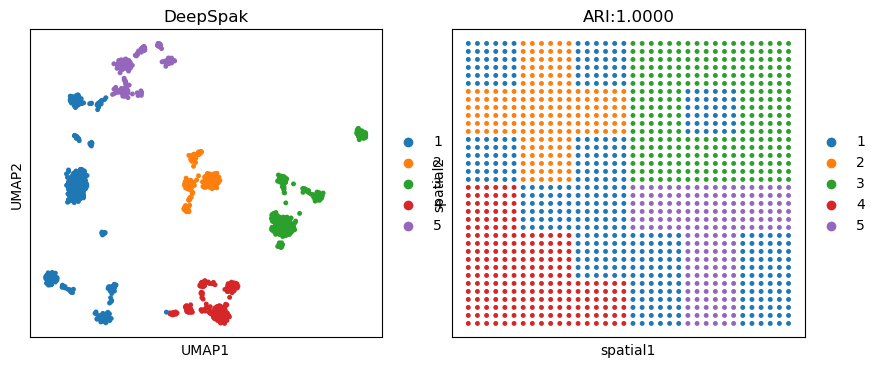

In [65]:
# =============================================================================
# Spatial embedding visualization
# =============================================================================
sc.pp.neighbors(adata, use_rep='emb_combined')
sc.tl.umap(adata)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sc.pl.umap(adata, color='DeepSpak', ax=ax[0], s=50, show=False)
sc.pl.embedding(adata, basis='spatial', color='DeepSpak', ax=ax[1], s=50, show=False,title=f'ARI:{ari:.4f}')
plt.show()
